# 9.1

Confidence: 9

In [7]:
import os
from dotenv import load_dotenv
from pymongo import MongoClient
from urllib.parse import quote_plus
import matplotlib.pyplot as plt

load_dotenv()

# Use the specific variable names
USERNAME = os.getenv("MONGODB_USERNAME")
PASSWORD = os.getenv("MONGODB_PASSWORD")

print(USERNAME)
print(PASSWORD)

dylanlidailin
8qLqbOJbQxZoeUkl


In [3]:
uri = (
    "mongodb+srv://"
    f"{quote_plus(USERNAME)}:{quote_plus(PASSWORD)}"
    "@cluster0.wxor8.mongodb.net/"
    "?appName=Cluster0"
)

#print(uri)
client = MongoClient(uri)

client.admin.command("ping")
db = client["esd4uq"]
col = db["HW9"]

In [7]:
import json
from pathlib import Path

FHIR_DIR = Path("fhir")

docs = []
for fp in FHIR_DIR.glob("*.json"): # Grab all the json files in the fhir folder
    bundle = json.loads(fp.read_text(encoding="utf-8"))
    assert bundle.get("resourceType") == "Bundle"

    patient_id = None
    for ent in bundle.get("entry", []):
        res = ent.get("resource")
        if not res:
            continue

        # track patient id for easier joins later
        if res.get("resourceType") == "Patient":
            patient_id = res.get("id")

        res["_source_file"] = fp.name
        if patient_id:
            res["_patient_id"] = patient_id

        docs.append(res)

# Insert
BATCH = 5000
for i in range(0, len(docs), BATCH):
    col.insert_many(docs[i:i+BATCH])

# 9.2

Confidence: 8

In [8]:
from collections import defaultdict

# Find all patients diagnosed with acute bronchitis
bronchitis_patient_ids = {
    doc["_patient_id"]
    for doc in col.find({
        "resourceType": "Condition",
        "code.coding": {"$elemMatch": {"display": {"$regex": "Acute bronchitis", "$options": "i"}}}
    })
}

# Get patient names
patient_names = {}
for pid in bronchitis_patient_ids:
    p = col.find_one({"resourceType": "Patient", "_patient_id": pid})
    if p:
        n = p.get("name", [{}])[0]
        patient_names[pid] = f"{' '.join(n.get('given', []))} {n.get('family', '')}".strip()

# Sum pharmacy claim totals per patient
# Pharmacy Claim.total.value = the patient's out-of-pocket medication cost
med_oop = defaultdict(float)
for claim in col.find({
    "resourceType": "Claim",
    "type.coding": {"$elemMatch": {"code": "pharmacy"}},
    "_patient_id": {"$in": list(bronchitis_patient_ids)}
}):
    med_oop[claim["_patient_id"]] += claim.get("total", {}).get("value", 0)

# Print results — include all bronchitis patients even if $0
print(f"  {'Patient Name':<37} {'OOP Med Cost ($)':>16}")
print(f"  {'─'*37} {'─'*16}")
grand_total = 0
for pid in sorted(bronchitis_patient_ids):
    name = patient_names.get(pid, "Unknown")
    cost = med_oop[pid]
    grand_total += cost
    print(f"  {name:<37} {cost:>16.2f}")

print(f"  {'─'*37} {'─'*16}")
print(f"  Total patients : {len(bronchitis_patient_ids)}")
print(f"  Total OOP cost : ${grand_total:,.2f}")

  Patient Name                          OOP Med Cost ($)
  ───────────────────────────────────── ────────────────
  Tanner110 Hoeger474                               7.54
  Eloise59 Gerhold939                            6352.72
  Regenia619 Gibson10                              63.78
  Maye976 Dickinson688                           1369.36
  Shanda945 Cremin516                             149.23
  Yuonne878 Dooley940                            4503.58
  Ezequiel972 Gulgowski816                         28.08
  Fleta652 Pollich983                               7.42
  Brendan864 Grady603                           27303.08
  Bryon392 Howell947                               35.76
  David908 Heidenreich818                       20261.65
  Hershel911 Lang846                               11.49
  Shaun461 Franecki195                             14.28
  Ramona980 Cordero852                              5.15
  Paz9 Murphy561                                 6273.43
  Reyes140 White193            

# 9.3

Confidence: 7

In [ ]:
from collections import defaultdict
from datetime import datetime, timezone

TODAY = datetime.now(timezone.utc)

def parse_dt(s):
    """Parse FHIR dateTime string to an aware datetime."""
    for fmt in ("%Y-%m-%dT%H:%M:%S%z", "%Y-%m-%dT%H:%M:%S.%f%z", "%Y-%m-%d"):
        try:
            dt = datetime.strptime(s, fmt)
            if dt.tzinfo is None:
                dt = dt.replace(tzinfo=timezone.utc)
            return dt
        except ValueError:
            continue
    return None

# Sum care plan durations per patient (all care plans, not just bronchitis ones)
care_plan_days = defaultdict(float)

for cp in col.find({
    "resourceType": "CarePlan",
    "_patient_id": {"$in": list(bronchitis_patient_ids)}
}):
    start_str = cp.get("period", {}).get("start")
    end_str   = cp.get("period", {}).get("end")
    if not start_str:
        continue
    start = parse_dt(start_str)
    end   = parse_dt(end_str) if end_str else TODAY
    if start and end:
        care_plan_days[cp["_patient_id"]] += (end - start).days

# Print results — all bronchitis patients, even those with 0 care plan days
print(f"  {'Patient Name':<37} {'Total Care Plan Days':>20}")
print(f"  {'─'*37} {'─'*20}")
grand_total_days = 0
for pid in sorted(bronchitis_patient_ids):
    name = patient_names.get(pid, "Unknown")
    days = care_plan_days[pid]
    grand_total_days += days
    print(f"  {name:<37} {days:>20.0f}")

print(f"  {'─'*37} {'─'*20}")
print(f"  Total patients       : {len(bronchitis_patient_ids)}")
print(f"  Total care plan days : {grand_total_days:,.0f}")

  Patient Name                          Total Care Plan Days
  ───────────────────────────────────── ────────────────────
  Tanner110 Hoeger474                                  17373
  Eloise59 Gerhold939                                   6814
  Regenia619 Gibson10                                     80
  Maye976 Dickinson688                                 34351
  Shanda945 Cremin516                                    916
  Yuonne878 Dooley940                                  17006
  Ezequiel972 Gulgowski816                              4243
  Fleta652 Pollich983                                  28741
  Brendan864 Grady603                                  56583
  Bryon392 Howell947                                    3931
  David908 Heidenreich818                               4630
  Hershel911 Lang846                                     834
  Shaun461 Franecki195                                  7486
  Ramona980 Cordero852                                  1858
  Paz9 Murphy561        

# 9.4

Confidence: 7

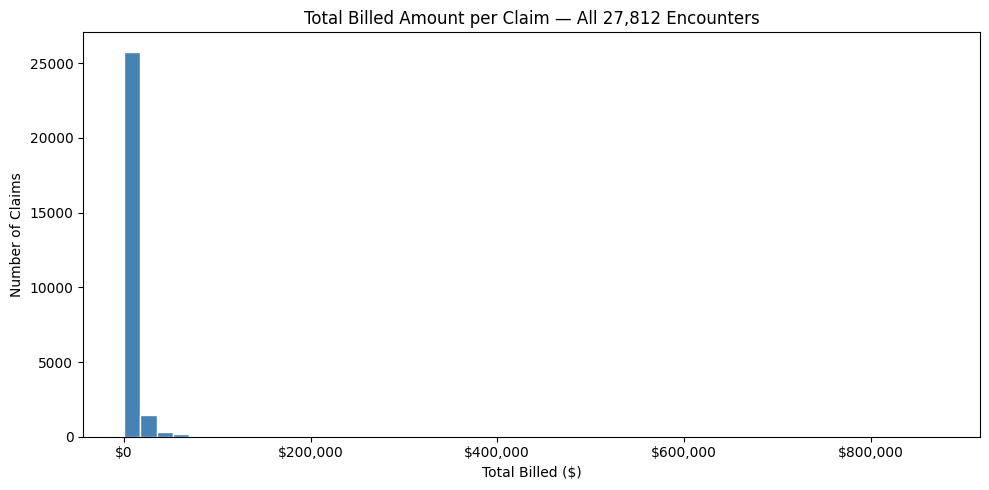

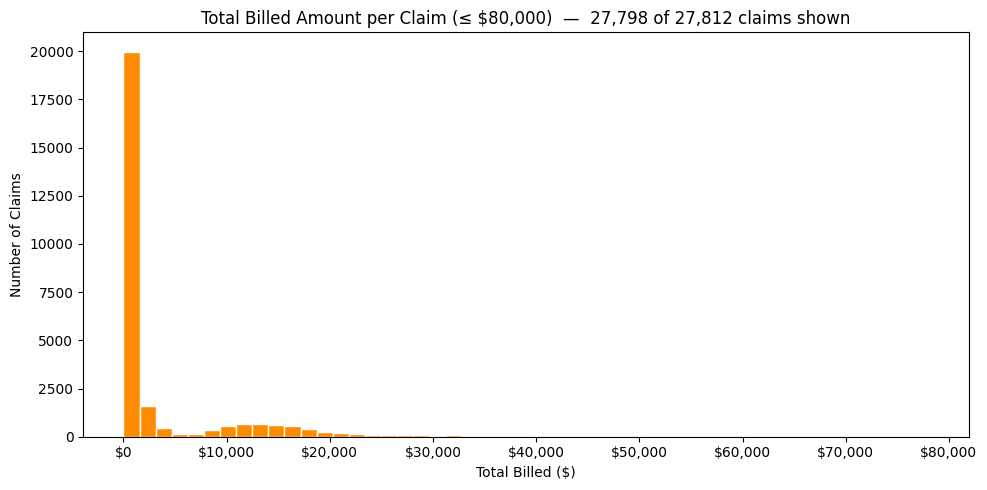

Total claims : 27,812
Shown in chart 2 (≤ $80k) : 27,798  (99.9%)
Excluded (> $80k) : 14


In [ ]:
# Pull the submitted (billed) amount from every ExplanationOfBenefit
amounts = []
for doc in col.find({"resourceType": "ExplanationOfBenefit"}):
    for t in doc.get("total", []):
        code = t.get("category", {}).get("coding", [{}])[0].get("code")
        val  = t.get("amount", {}).get("value")
        if code == "submitted" and val is not None:
            amounts.append(val)

# Chart 1 — all encounter claims
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(amounts, bins=50, color="steelblue", edgecolor="white")
ax.set_title(f"Total Billed Amount per Claim — All {len(amounts):,} Encounters")
ax.set_xlabel("Total Billed ($)")
ax.set_ylabel("Number of Claims")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.show()

# Chart 2 — claims up to $80,000
amounts_filtered = [a for a in amounts if a <= 80_000]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(amounts_filtered, bins=50, color="darkorange", edgecolor="white")
ax.set_title(
    f"Total Billed Amount per Claim (≤ $80,000)"
    f"  —  {len(amounts_filtered):,} of {len(amounts):,} claims shown"
)
ax.set_xlabel("Total Billed ($)")
ax.set_ylabel("Number of Claims")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.show()

print(f"Total claims : {len(amounts):,}")
print(f"Shown in chart 2 (≤ $80k) : {len(amounts_filtered):,}  ({100*len(amounts_filtered)/len(amounts):.1f}%)")
print(f"Excluded (> $80k) : {len(amounts) - len(amounts_filtered):,}")

# 9.5

Confidence: 8

# Headline

Synthetic health records rank stress and employment among the most frequent “conditions” in a Synthea sample

# Why this matters

Electronic health data are not only lists of diseases. In FHIR, patients' condition is reflective of health problems, social circumstances, and other physical and psychological findings. FHIR data delivers an alarming message that stress and employment are the leading causes of patients' condition. The discovery points at how stress induces health issues and the impact of a toxic workplace culture.

# Detailed description

A review of FHIR Condition resources in a Synthea FHIR extract counted distinct patients associated with each condition label and ranked the top 15. Stress (finding) appeared most often—on the order of 400+ patients in this sample—followed closely by full-time employment (finding) and viral sinusitis (disorder). Several other high-ranking entries reflect social determinants and life context rather than acute disease: part-time employment, social isolation, limited social contact, higher education, not in labor force, intimate partner abuse, violence in the environment, and obesity (BMI 30+). Classic acute-care patterns still show up: acute viral pharyngitis, acute bronchitis, and common chronic or lab-adjacent labels such as prediabetes and anemia appear in the same leaderboard. The pattern underscores that “top conditions” in this file mix clinical disorders with social and well-being findings—a design choice in the synthetic data, not a claim about real-world disease rates.

# Visualization

The horizontal bar chart titled “Top 15 conditions by patient count (Synthea FHIR sample)” shows each label’s count of distinct patients, with stress and employment-related findings leading the list alongside common respiratory disorders.

In [5]:
# 9.5 condition prevalence (distinct patients per diagnosis)
from collections import defaultdict

patient_per_label = defaultdict(set)

for doc in col.find({"resourceType": "Condition"}):
    pid = doc.get("_patient_id")
    if not pid:
        continue
    for c in doc.get("code", {}).get("coding", []):
        label = c.get("display")
        if label:
            patient_per_label[label].add(pid)

# sort by patient count
rows = sorted(
    ((label, len(pids)) for label, pids in patient_per_label.items()),
    key=lambda x: -x[1],
)
TOP_N = 15
top = rows[:TOP_N]
labels, counts = zip(*top) if top else ([], [])

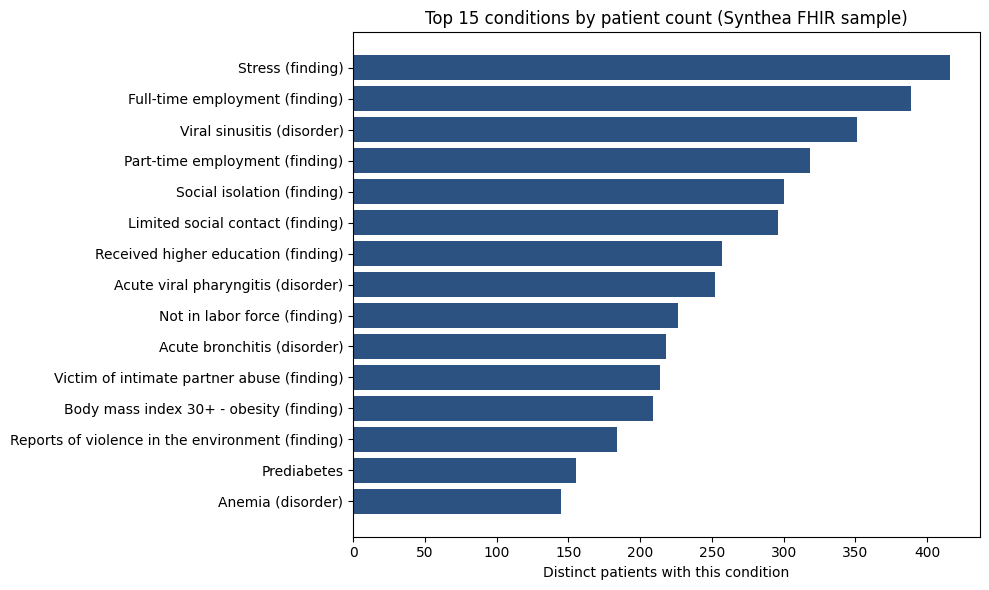

Unique condition labels: 193
Patients in data (approx): 549


In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(list(reversed(labels)), list(reversed(counts)), color="#2c5282")
ax.set_xlabel("Distinct patients with this condition")
ax.set_title(f"Top {TOP_N} conditions by patient count (Synthea FHIR sample)")
plt.tight_layout()
plt.show()

print(f"Unique condition labels: {len(patient_per_label):,}")
print(f"Patients in data (approx): {len({p for s in patient_per_label.values() for p in s}):,}")

# 9.6

Confidence: 7

In HW5 I worked with normalized CSV exports where each entity lived in its own file (patients, conditions, medications, care plans, claims, etc.) while being tied together by a shared patient key. I then use SQL to express the same relationships with basic commands such as INSERT, SELECT, and joins. In HW9 I loaded the same FHIR dataset into MongoDB as individual FHIR documents by resourceType, which serves as a natural aggregate for the patient's medical information. Within each document, clinical meaning was buried in nested arrays: to find a patient's diagnosis label I had to traverse code.coding[].display. For example, I use "Condition" to find diagnoses, "Claim" to find costs, "CarePlan" for care durations. To get a care plan's length I had to parse period.start and period.end out of ISO date strings. Instead of building a relational schema where each entity has its own table with columns and foreign keys, I aggregated across documents by collecting patient IDs into sets, summing costs into dictionaries, and counting condition labels with counters before the visualization step. The upside was that I don't need to design a schema or run any SQL. Every resource was imported straight into the collection in MongoDB Atlas. But the tradeoff was that the path from raw data to a plottable number required understanding the FHIR spec and unpacking nested structure at every step, which was less obvious than writing a SQL join in HW5.

For visualization, HW5 offers an simpler solution than HW9. In HW5, once I had joined tables in pandas, the histogram for claim or transaction amounts was mostly plt.hist on a single Series or column — the heavy lifting was already done in the DataFrame. In HW9, matplotlib was the same library, but the chart came after a separate extraction step: for 9.4 I pulled submitted amounts from each ExplanationOfBenefit into a Python list, then histogrammed that list, including a second plot capped at $80,000 to see the bulk of the distribution. For 9.5 I aggregated condition labels into counts, then fed those labels and counts into a horizontal bar chart. So in HW5 the plot sat on top of a table; in HW9 I build the table (or parallel arrays) by hand from nested documents before plotting.

# 9.7

# Problem Definition

Confidence: 7